# Implementing Hypothesis Testing Procedures

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement hypothesis testing procedures
- Understand null and alternative hypotheses
- Perform t-tests and chi-square tests
- Interpret test results and make decisions

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — you measured the spread and skew of a real 891-passenger manifest; a hypothesis test is how you argue that a difference in data that noisy is not just the noise.

**Used later in:** Course 06 (AIAT 116) — Unit 2, lesson 01 "Bias Detection in Machine Learning Models" — deciding whether a measured fairness disparity is real.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Implementing hypothesis testing procedures

---

## Introduction

**Hypothesis testing** is a statistical method for making decisions about population parameters based on sample data. We test a null hypothesis against an alternative hypothesis.


---

## 📌 Real case: 100 psychology studies, 36 that replicated

In 2015 the **Open Science Collaboration** — 270 authors — published *"Estimating the reproducibility of
psychological science"* in *Science*. They repeated **100 studies** from three leading psychology journals,
working with the original materials and, where possible, the original authors. Of the **97 original studies
that had reported a statistically significant effect, only 36% produced a significant result on
replication**, and the replication effect sizes averaged about **half** the originals. The pattern differed
by field: roughly 50% for cognitive psychology, roughly 25% for social psychology.

Every one of those 97 original findings had passed the test you are about to run, at the threshold you are
about to use. That is what makes the number worth staring at. p < 0.05 does not mean "true". It means
"data this extreme would be uncommon if the null hypothesis held" — and if enough researchers test enough
hypotheses, uncommon things happen constantly.

**What goes wrong without this.** A p-value is a statement about data under an assumption, and people read
it as a statement about the world. The consequence is a literature — and, increasingly, a machine-learning
literature — full of effects that were real in one sample and nowhere else.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy, Matplotlib, and scipy.stats - the t-test and chi-square machinery lives
# in SciPy - plus pandas to load the real Titanic passenger records we test.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nImplementing Hypothesis Testing Procedures")
print("=" * 60)


✅ Libraries imported!

Implementing Hypothesis Testing Procedures


## Part 1: One-Sample t-Test


Part 1: One-Sample t-Test

Data: recorded ages of Titanic passengers
  Records with a recorded age: 714 of 891 (177 missing)

Sample statistics:
  Sample mean: 29.6991 years
  Sample std: 14.5265
  Sample size: 714

Hypothesis Test:
  H0: μ = 28 (the claim under test)
  H1: μ ≠ 28
  Significance level (α): 0.05

Results:
  t-statistic: 3.1254
  p-value: 0.001847

  Decision: Reject H0 (p < α)
  Conclusion: Sample mean is significantly different from 28

Same test against H0: μ = 30  ->  t = -0.5535, p = 0.5801 (fail to reject)
Two claims only 2 years apart, two opposite verdicts. That is what a p-value
measures: how surprising THIS data would be if the claim were true.

Caveat worth stating out loud: the 177 passengers with no recorded age are
excluded here. If age was missing more often for third-class passengers, this
test describes the recorded subset, not everyone aboard.


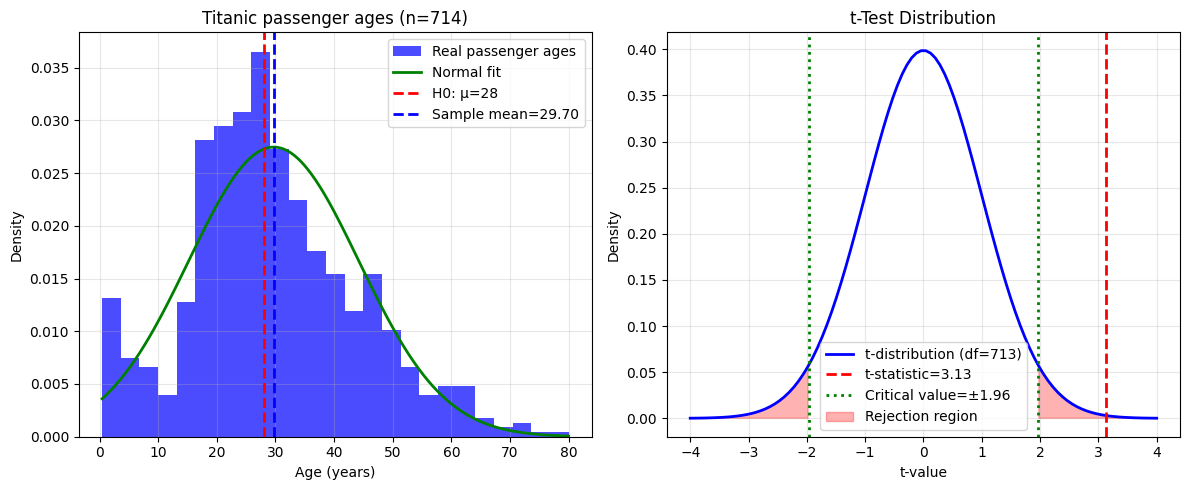


✅ One-sample t-test performed on real data!


In [2]:
# One-sample t-test walkthrough on REAL data: state H0, compute the t statistic and
# p-value, decide at alpha = 0.05. The right panel shades the rejection region so
# "p < alpha" becomes a picture, not a slogan.

print("=" * 60)
print("Part 1: One-Sample t-Test")
print("=" * 60)

# Real data: the recorded ages of RMS Titanic passengers. 177 of the 891 records have no
# age at all - real datasets have holes - so we test the 714 that do.
titanic = pd.read_csv(data_path("titanic.csv"))
sample = titanic["Age"].dropna().to_numpy()
sample_size = len(sample)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

print(f"\nData: recorded ages of Titanic passengers")
print(f"  Records with a recorded age: {sample_size} of {len(titanic)} "
      f"({titanic['Age'].isna().sum()} missing)")
print(f"\nSample statistics:")
print(f"  Sample mean: {sample_mean:.4f} years")
print(f"  Sample std: {sample_std:.4f}")
print(f"  Sample size: {sample_size}")

# The claim we are testing: a historian asserts the typical passenger was 28 years old.
# Hypothesis test: H0: mu = 28, H1: mu != 28
hypothesized_mean = 28
alpha = 0.05  # Significance level

# Perform t-test
t_statistic, p_value = stats.ttest_1samp(sample, hypothesized_mean)

print(f"\nHypothesis Test:")
print(f"  H0: μ = {hypothesized_mean} (the claim under test)")
print(f"  H1: μ ≠ {hypothesized_mean}")
print(f"  Significance level (α): {alpha}")
print(f"\nResults:")
print(f"  t-statistic: {t_statistic:.4f}")
print(f"  p-value: {p_value:.6f}")

# Decision
if p_value < alpha:
    print(f"\n  Decision: Reject H0 (p < α)")
    print(f"  Conclusion: Sample mean is significantly different from {hypothesized_mean}")
else:
    print(f"\n  Decision: Fail to reject H0 (p ≥ α)")
    print(f"  Conclusion: No significant evidence that mean differs from {hypothesized_mean}")

# The same machinery on a nearby claim, to show that "significant" is about the DATA,
# not about the size of the difference alone.
t2, p2 = stats.ttest_1samp(sample, 30)
print(f"\nSame test against H0: μ = 30  ->  t = {t2:.4f}, p = {p2:.4f} "
      f"({'reject' if p2 < alpha else 'fail to reject'})")
print("Two claims only 2 years apart, two opposite verdicts. That is what a p-value")
print("measures: how surprising THIS data would be if the claim were true.")
print("\nCaveat worth stating out loud: the 177 passengers with no recorded age are")
print("excluded here. If age was missing more often for third-class passengers, this")
print("test describes the recorded subset, not everyone aboard.")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(sample, bins=25, density=True, alpha=0.7, color='blue', label='Real passenger ages')
x = np.linspace(sample.min(), sample.max(), 200)
plt.plot(x, stats.norm.pdf(x, sample_mean, sample_std), 'g-', linewidth=2, label='Normal fit')
plt.axvline(hypothesized_mean, color='r', linestyle='--', linewidth=2, label=f'H0: μ={hypothesized_mean}')
plt.axvline(sample_mean, color='b', linestyle='--', linewidth=2, label=f'Sample mean={sample_mean:.2f}')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.title('Titanic passenger ages (n=%d)' % sample_size)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
df = sample_size - 1
x = np.linspace(-4, 4, 100)
t_dist = stats.t.pdf(x, df)
plt.plot(x, t_dist, 'b-', linewidth=2, label=f't-distribution (df={df})')
plt.axvline(t_statistic, color='r', linestyle='--', linewidth=2, label=f't-statistic={t_statistic:.2f}')
critical_value = stats.t.ppf(1 - alpha/2, df)
plt.axvline(critical_value, color='g', linestyle=':', linewidth=2, label=f'Critical value=±{critical_value:.2f}')
plt.axvline(-critical_value, color='g', linestyle=':', linewidth=2)
plt.fill_between(x, 0, t_dist, where=(x <= -critical_value) | (x >= critical_value), alpha=0.3, color='red', label='Rejection region')
plt.xlabel('t-value')
plt.ylabel('Density')
plt.title('t-Test Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ One-sample t-test performed on real data!")


## Part 2: Two-Sample t-Test



Part 2: Two-Sample t-Test

Sample 1 - fares paid by survivors:
  Mean: 48.3954, Std: 66.5970, Size: 342

Sample 2 - fares paid by those who died:
  Mean: 22.1179, Std: 31.3882, Size: 549

Hypothesis Test:
  H0: μ1 = μ2 (survivors and non-survivors paid the same on average)
  H1: μ1 ≠ μ2
  Significance level (α): 0.05

Results (Welch's t-test):
  t-statistic: 6.8391
  p-value: 2.699e-11

  Decision: Reject H0
  Conclusion: Means are significantly different

Same test on AGE instead of fare: 28.34 vs 30.63 years, t = -2.046, p = 0.0412
A borderline result: real effects are not all dramatic, and a p-value just under
0.05 is weak evidence, not proof. Report the effect size alongside it.

Mean difference (survivors - non-survivors): £26.2775


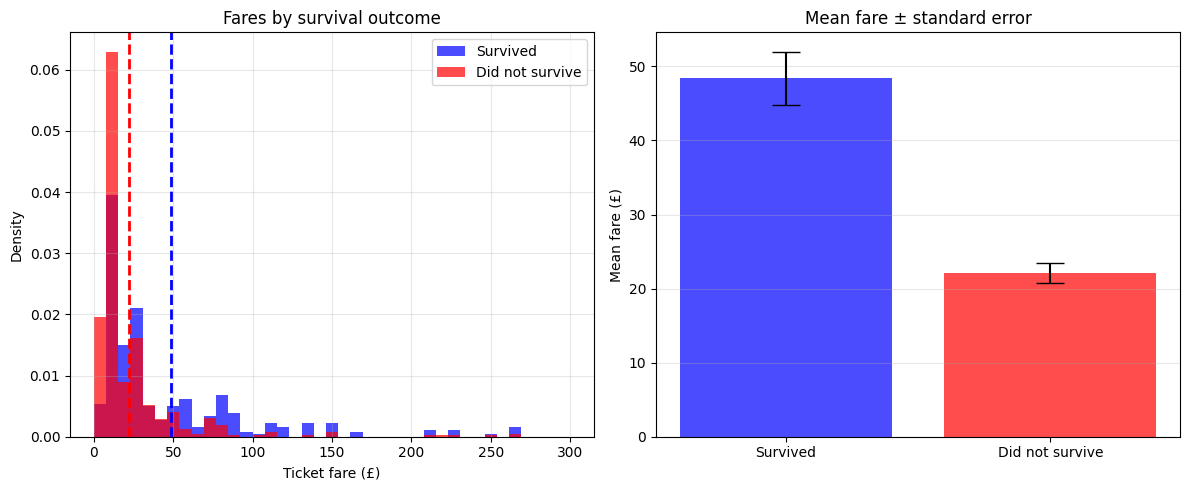


What the test does NOT say: paying more did not cause survival. Fare is a proxy
for cabin class and deck position - association, not causation.

✅ Two-sample t-test performed on real data!


In [3]:
# Two-sample t-test on REAL groups: did the passengers who survived pay more for their
# tickets than those who did not? This is THE test behind A/B experiments and
# model-comparison claims - here the two "groups" are two real sets of people.

print("\n" + "=" * 60)
print("Part 2: Two-Sample t-Test")
print("=" * 60)

sample1 = titanic.loc[titanic["Survived"] == 1, "Fare"].to_numpy()   # survivors
sample2 = titanic.loc[titanic["Survived"] == 0, "Fare"].to_numpy()   # did not survive

print(f"\nSample 1 - fares paid by survivors:")
print(f"  Mean: {np.mean(sample1):.4f}, Std: {np.std(sample1, ddof=1):.4f}, Size: {len(sample1)}")
print(f"\nSample 2 - fares paid by those who died:")
print(f"  Mean: {np.mean(sample2):.4f}, Std: {np.std(sample2, ddof=1):.4f}, Size: {len(sample2)}")

# Hypothesis test: H0: mu1 = mu2, H1: mu1 != mu2
alpha = 0.05

# Welch's t-test (equal_var=False): the two groups have very different spreads and sizes,
# and Welch does not assume they match. Use it as your default for real-world groups.
t_statistic, p_value = stats.ttest_ind(sample1, sample2, equal_var=False)

print(f"\nHypothesis Test:")
print(f"  H0: μ1 = μ2 (survivors and non-survivors paid the same on average)")
print(f"  H1: μ1 ≠ μ2")
print(f"  Significance level (α): {alpha}")
print(f"\nResults (Welch's t-test):")
print(f"  t-statistic: {t_statistic:.4f}")
print(f"  p-value: {p_value:.3e}")

if p_value < alpha:
    print(f"\n  Decision: Reject H0")
    print(f"  Conclusion: Means are significantly different")
else:
    print(f"\n  Decision: Fail to reject H0")
    print(f"  Conclusion: No significant difference between means")

# A second, much subtler comparison from the same dataset.
age1 = titanic.loc[titanic["Survived"] == 1, "Age"].dropna().to_numpy()
age2 = titanic.loc[titanic["Survived"] == 0, "Age"].dropna().to_numpy()
t_age, p_age = stats.ttest_ind(age1, age2, equal_var=False)
print(f"\nSame test on AGE instead of fare: "
      f"{np.mean(age1):.2f} vs {np.mean(age2):.2f} years, t = {t_age:.3f}, p = {p_age:.4f}")
print("A borderline result: real effects are not all dramatic, and a p-value just under")
print("0.05 is weak evidence, not proof. Report the effect size alongside it.")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bins = np.linspace(0, 300, 40)
plt.hist(sample1, bins=bins, density=True, alpha=0.7, color='blue', label='Survived')
plt.hist(sample2, bins=bins, density=True, alpha=0.7, color='red', label='Did not survive')
plt.axvline(np.mean(sample1), color='blue', linestyle='--', linewidth=2)
plt.axvline(np.mean(sample2), color='red', linestyle='--', linewidth=2)
plt.xlabel('Ticket fare (£)')
plt.ylabel('Density')
plt.title('Fares by survival outcome')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
mean_diff = np.mean(sample1) - np.mean(sample2)
print(f"\nMean difference (survivors - non-survivors): £{mean_diff:.4f}")
plt.bar(['Survived', 'Did not survive'], [np.mean(sample1), np.mean(sample2)],
        yerr=[np.std(sample1, ddof=1)/np.sqrt(len(sample1)),
              np.std(sample2, ddof=1)/np.sqrt(len(sample2))],
        alpha=0.7, color=['blue', 'red'], capsize=10)
plt.ylabel('Mean fare (£)')
plt.title('Mean fare ± standard error')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nWhat the test does NOT say: paying more did not cause survival. Fare is a proxy")
print("for cabin class and deck position - association, not causation.")
print("\n✅ Two-sample t-test performed on real data!")


## Part 3: Chi-Square Test for Independence


In [4]:
# Chi-square test of independence on a REAL contingency table of counts.
# It asks: do the observed cell counts stray too far from what independence would predict?

print("\n" + "=" * 60)
print("Part 3: Chi-Square Test for Independence")
print("=" * 60)

# Real contingency table: passenger class vs survival, straight from the Titanic manifest.
# No numbers are invented - each cell is a head count.
table = pd.crosstab(titanic["Pclass"], titanic["Survived"])
table.index = [f"Class {i}" for i in table.index]
table.columns = ["Died", "Survived"]
observed = table.to_numpy()

print("\nObserved frequencies (contingency table of real passengers):")
print(table)

# Hypothesis test: H0: Variables are independent, H1: Variables are dependent
alpha = 0.05

# Perform chi-square test
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(observed)

print(f"\nHypothesis Test:")
print(f"  H0: survival is independent of passenger class")
print(f"  H1: survival depends on passenger class")
print(f"  Significance level (α): {alpha}")
print(f"\nResults:")
print(f"  χ² statistic: {chi2_statistic:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p_value:.3e}")
print(f"\nExpected frequencies IF class made no difference:")
print(pd.DataFrame(expected.round(1), index=table.index, columns=table.columns))

if p_value < alpha:
    print(f"\n  Decision: Reject H0")
    print(f"  Conclusion: Survival and passenger class are NOT independent")
else:
    print(f"\n  Decision: Fail to reject H0")
    print(f"  Conclusion: No evidence of dependence")

# Say what the table actually shows, in plain numbers.
rates = titanic.groupby("Pclass")["Survived"].mean()
print("\nSurvival rate by class:")
for cls, rate in rates.items():
    print(f"  Class {cls}: {rate:.1%}")
print("This is a real historical inequality, and the chi-square test is how you state")
print("that it is far too large to be a fluke of who happened to be aboard.")

print("\n✅ Chi-square test performed on real data!")



Part 3: Chi-Square Test for Independence

Observed frequencies (contingency table of real passengers):
         Died  Survived
Class 1    80       136
Class 2    97        87
Class 3   372       119

Hypothesis Test:
  H0: survival is independent of passenger class
  H1: survival depends on passenger class
  Significance level (α): 0.05

Results:
  χ² statistic: 102.8890
  Degrees of freedom: 2
  p-value: 4.549e-23

Expected frequencies IF class made no difference:
          Died  Survived
Class 1  133.1      82.9
Class 2  113.4      70.6
Class 3  302.5     188.5

  Decision: Reject H0
  Conclusion: Survival and passenger class are NOT independent

Survival rate by class:
  Class 1: 63.0%
  Class 2: 47.3%
  Class 3: 24.2%
This is a real historical inequality, and the chi-square test is how you state
that it is far too large to be a fluke of who happened to be aboard.

✅ Chi-square test performed on real data!


---

## ⚠️ Where this breaks

- **The same data gives opposite verdicts for hypotheses two years apart.** Part 1 tests the Titanic ages
  against H₀: μ = 28 and rejects it (p = 0.001847); against H₀: μ = 30 it fails to reject (p = 0.5801).
  Nothing about the world changed. A p-value scores a *specific claim* against your data — it does not
  measure how true a theory is, and "significant" is not a property the data possesses.
- **Statistical significance is not effect size.** The two-sample test on fares gives p = 2.7 × 10⁻¹¹ for a
  £26 difference; the same test on ages gives p = 0.0412 for a 2.3-year difference. The first is a large
  effect strongly evidenced, the second a small effect weakly evidenced, and only the effect sizes tell them
  apart. The notebook says it outright: "a p-value just under 0.05 is weak evidence, not proof."
- **The missing data is not random.** 177 of 891 passengers have no recorded age, and the notebook flags the
  consequence: if age went unrecorded more often for third-class passengers, this test describes the
  *recorded subset*, not everyone aboard. No p-value can detect that.
- **Association is not causation, and χ² is not an explanation.** Survival rates by class (63.0%, 47.3%,
  24.2%, χ² = 102.9, p = 4.5 × 10⁻²³) establish that class and survival are not independent. They do not
  establish what a first-class ticket *did* — deck position, lifeboat proximity, crew instructions and age
  composition all travel with it.
- **Each extra test buys an extra chance of a false positive.** This notebook runs five. At α = 0.05, the
  probability of at least one spurious "significant" result among five independent tests of true nulls is
  about 23%. Correct for multiplicity (Bonferroni, Benjamini–Hochberg) whenever you test more than one
  thing — and note that "trying a few different comparisons until one works" is the same problem, unrecorded.


---

## 💬 Discuss

1. 97 published findings passed p < 0.05; 36% replicated. Does that mean the threshold is wrong, the
   incentives are wrong, or both? Propose one concrete change and say who would resist it.
2. Testing H₀: μ = 28 rejects and H₀: μ = 30 does not, on identical data. Write the sentence you would use
   to explain to a non-statistician what a p-value therefore *is*.
3. The fare test (p = 2.7 × 10⁻¹¹) proves survivors paid more, and proves nothing about why. Design a
   study — with data that could plausibly exist — that would move you closer to a causal claim, and say
   what would still be missing.


## Summary

### Key Concepts:
1. **Null Hypothesis (H0)**: Default assumption to test
2. **Alternative Hypothesis (H1)**: Research hypothesis
3. **p-value**: the probability of a test statistic **at least as extreme as the one observed**, computed in a world where H0 is true. It is not the probability that H0 is true, and not the probability that the result arose by chance alone (ASA, 2016 - reference 3 below). This is the definition used everywhere in the diploma, including the drift detectors in Course 11 (AIAT 125), Unit 5.
4. **Significance Level (α)**: Threshold for rejecting H0 (typically 0.05)
5. **Type I Error**: Rejecting H0 when it's true (false positive)
6. **Type II Error**: Failing to reject H0 when it's false (false negative)

### Test Types:
- **t-test**: Compare means (one-sample, two-sample, paired)
- **z-test** (for reference — not demonstrated in this notebook): like the t-test, but used when the population variance is known
- **Chi-square test**: Test independence of categorical variables

### Best Practices:
- Set significance level before testing
- Interpret p-values correctly (not probability H0 is true)
- Consider effect size, not just statistical significance
- Report confidence intervals along with p-values

### Applications:
- Scientific research
- Quality control
- A/B testing
- Medical studies

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - Hypothesis testing practical content

---

> **🔤 Notation warning — α is overloaded, and this is its second job in this course.** Here **α is the
> significance level**, the false-positive rate you are willing to accept before you look at the data
> (conventionally 0.05). In Unit 1, lesson 08 and Unit 3, lesson 04 the same letter α was the
> **regularization strength** of Ridge and Lasso — the `alpha=` argument in scikit-learn — and in
> lesson 03 of this unit α is a **shape parameter of the Beta distribution**. Three unrelated
> quantities, one Greek letter, all three standard in their own literature; the diploma keeps the
> field's conventions rather than inventing private ones. Always read α from its sentence, never from
> the symbol alone. `docs/GLOSSARY.md` lists every overloaded symbol in the diploma.

## 📚 References

1. Student [Gosset, W. S.] (1908). *The Probable Error of a Mean*. Biometrika, 6(1), 1–25.
2. Neyman, J., & Pearson, E. S. (1933). *On the Problem of the Most Efficient Tests of Statistical Hypotheses*. Philosophical Transactions of the Royal Society A, 231, 289–337.
3. Wasserstein, R. L., & Lazar, N. A. (2016). *The ASA Statement on p-Values: Context, Process, and Purpose*. The American Statistician, 70(2), 129–133. <https://doi.org/10.1080/00031305.2016.1154108>
4. Miller, E. (2024). *Adding Error Bars to Evals: A Statistical Approach to Language Model Evaluations*. arXiv. <https://arxiv.org/abs/2411.00640> — significance testing between two models: the test this notebook teaches, applied to evaluations.
5. Bowyer, S., Aitchison, L., & Ivanova, D. R. (2025). *Position: Don't Use the CLT in LLM Evals With Fewer Than a Few Hundred Datapoints*. arXiv. <https://arxiv.org/abs/2503.01747> — why the standard test is unreliable on small, specialized benchmarks.
